# 7. Light curves and post-processing - Under construction!

### Setup notebook

In [1]:
# Reload code outside notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [15]:
import os
import h5py
import scipy
import wotan
import numpy as np
import pandas as pd
from tqdm import tqdm

from matplotlib import pyplot as plt
import matplotlib.colors  as colors
import matplotlib.patches as patches

from astropy.io import fits
from astropy import units as u
from astropy.coordinates import SkyCoord

from scipy.signal import periodogram
from scipy.ndimage import median_filter
from scipy.interpolate import interp2d

# PlatoSim
import platosim.referenceFrames as rf
import platosim.plot            as pt
import platosim.utilities       as ut
from platosim.simulation   import Simulation
from platosim.simfile      import SimFile
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

## TESTING

In [16]:
lc = LightCurve('/lhome/nicholas/software/workdir/test/output/000000001/000000001_Ncam1.1_Q1.ftr')
dg = pd.read_feather('/lhome/nicholas/software/workdir/test/input/instrumentGap.ftr')

In [17]:
dg = dg.iloc[:312113]

In [18]:
df = lc.data().loc[~dg['all']] 

<IPython.core.display.Javascript object>


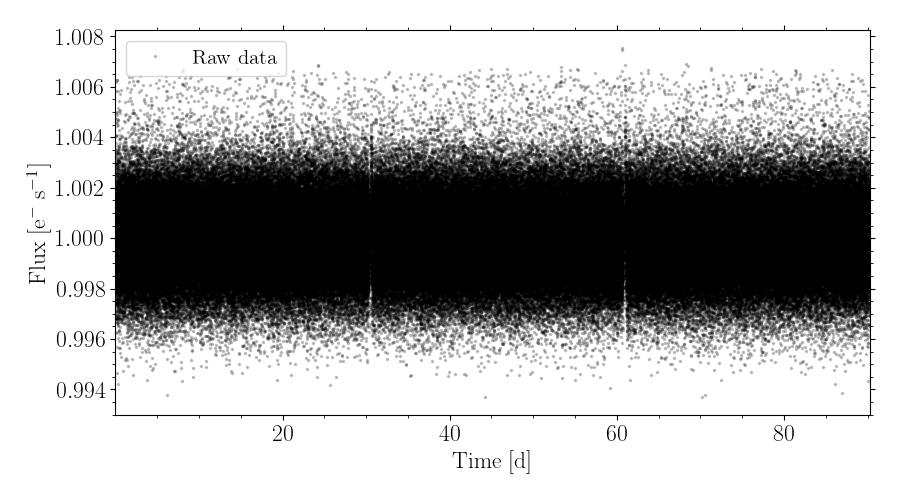

(<Figure size 900x500 with 1 Axes>,
 <Axes: xlabel='Time [d]', ylabel='Flux [e$^-$ s$^{-1}$]'>)

In [20]:
lc = LightCurve(df, mode='multi')
lc.plot()

/lhome/nicholas/software/PlatoSim3/python/platosim/lightcurve.py:970: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['flux_trend']   = flux_trend
/lhome/nicholas/software/PlatoSim3/python/platosim/lightcurve.py:971: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self.df['flux_detrend'] = flux_detrend


<IPython.core.display.Javascript object>


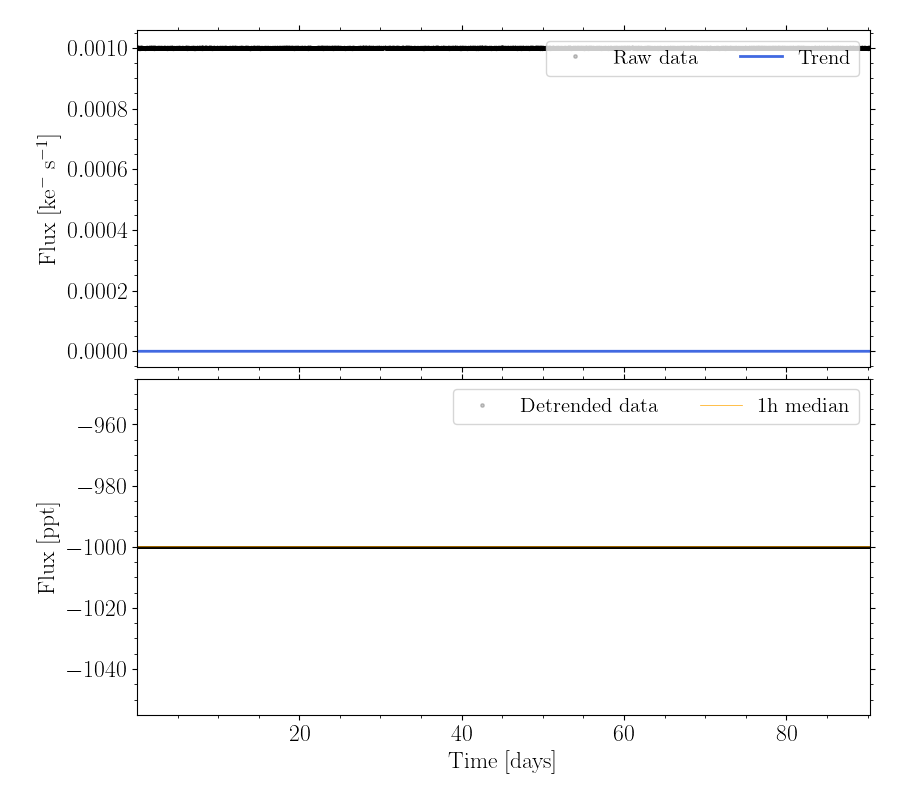

,time,flux,flux_trend,flux_detrend
0,12.5,0.998758,0.0,0.0
1,37.5,0.999196,0.0,0.0
2,62.5,1.000036,0.0,0.0
3,87.5,1.000255,0.0,0.0
4,112.5,0.999945,0.0,0.0
...,...,...,...,...
311880,7797012.5,1.000614,0.0,0.0
311881,7797037.5,0.999537,0.0,0.0
311882,7797062.5,0.998491,0.0,0.0
311883,7797087.5,0.998587,0.0,0.0


In [21]:
lc.detrend(model='wotan', plot=True)

In [23]:
len([])

0

In [40]:
df = lc.clip(model='wotan', sigma_lower=4, sigma_upper=4)

<IPython.core.display.Javascript object>


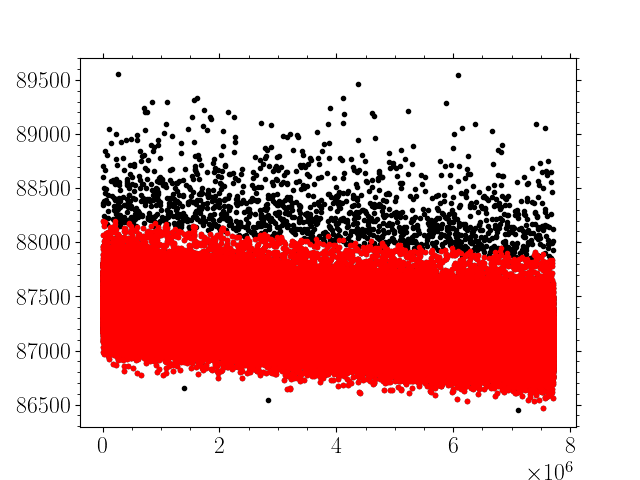

In [42]:
plt.figure()
plt.plot(df.time, df.flux, 'k.')
plt.plot(df.time, df.flux_clip, 'r.')

             time          flux     flux_clip    flux_trend  flux_detrend
0             0.0  87397.394157  87397.394157  87470.083356      0.999169
1            25.0  87786.821180  87786.821180  87470.082048      1.003621
2            50.0  87469.944325  87469.944325  87470.080740      0.999998
3            75.0  87286.625901  87286.625901  87470.079432      0.997903
4           100.0  87276.107851  87276.107851  87470.078124      0.997782
...           ...           ...           ...           ...           ...
308651  7716275.0  87117.444241  87117.444241  87135.040501      0.999798
308652  7716300.0  87461.308904  87461.308904  87135.039638      1.003744
308653  7716325.0  87217.344035  87217.344035  87135.038775      1.000945
308654  7716350.0  86987.399572  86987.399572  87135.037912      0.998306
308655  7716375.0  87052.773173  87052.773173  87135.037049      0.999056

[307236 rows x 5 columns]


<IPython.core.display.Javascript object>


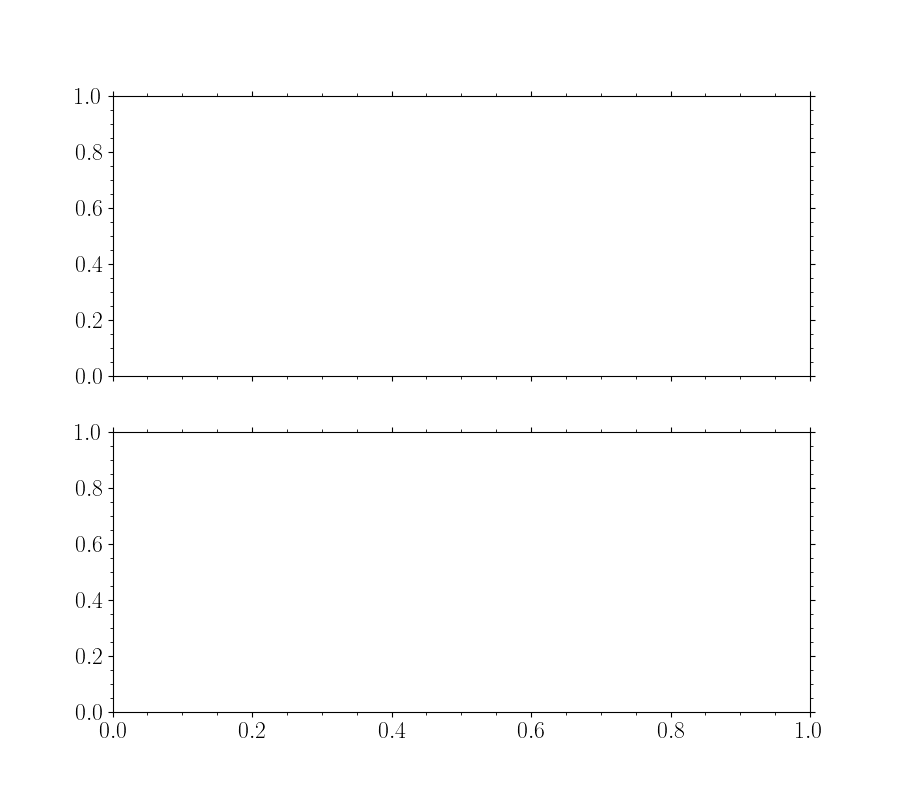

UnboundLocalError: local variable 'flux' referenced before assignment

In [48]:
df = lc.detrend(column='flux_clip', model='poly', degree=2, plot=True)

### Run a default simulation for the tutorial

In [ ]:
outputDir      = os.getcwd()
outputFile     = f"{outputDir}/{outputFileName}.hdf5"

---

##  Basic overview

We have alread touched upon how you can use the `SimFile` class to retrieve information from the HDF5 file. Here we dive in a bit deeper and show several functionalites. We will look at the following APIs:

In [ ]:
# Read path
path = '/lhome/nicholas/sims_kul21/jitterNone/000000001/' 

# Fetch all zip files
files = glob.glob(path+ "*.zip")

# Unpack zip files
with ZipFile(files[0], 'r') as unzip:
    unzip.extractall(path)
    
# Get file names
filename_ftr = files[0][:-3] + "ftr"
filename_cat = files[0][:-3] + "cat"

let's start by a simple example of extracting the simulated light curve and plotting a 1 hour binned curve on top which is the general time scale used in the PLATO mission for noise subpression of finding exoplanets.

In [ ]:
# Load feather file
lc = PhotometryFile(filename_ftr)

In [ ]:
# Get obs information; [group, camera, quarter] 
lc.obs()

In [ ]:
# Create a plot of 
fig, ax = lc.plot(flux_unit="e/s", errorbar=False, median_filter=True, binsize=1)
ax.set_title('Light curve example');

It is straight away to fetch the rebinned light curve shown above a red markers:

In [ ]:
time_bin, flux_bin, tdur_bin = lc.bin(unit="ppm")
flux_bin

## Photometric precision

To analyse the noise level in a ligth curve a few options are available. The first is the Noise-to-Signal Ratio (NSR) defined by:

$$
{\rm NSR}_{\rm 1h} = \frac{10^6}{\sqrt{144}}\frac{\sigma_F}{\bar{F}}
$$

In [ ]:
lc.getNSR()

It is easy to get the Root-Mean-Square of the noise level in a light curve defined by

$$
{\rm RMS}_{\rm 1h} = \frac{10^6}{\sqrt{144}}\frac{F_{\rm median}}{\bar{F}}
$$

In [ ]:
# Fetch NSR [ppm/sqrt(h)]
lc.getRMS(column="flux_med", unit="ppm")

Lastly the Median Absolute Deviation (MAD) can also be fetched by:

In [ ]:
lc.getMAD(column="flux_med", unit="ppm")

In [ ]:
# Mean flux error in percent
flux     = lc.flux()
flux_err = lc.flux_err()
flux_err_percent = flux_err.mean() / flux.mean() * 100
flux_err_percent

In [ ]:
# Mean centroid error in percent
xcen = lc.xcen(unit="pix")
ycen = lc.ycen(unit="pix")
xcen_err = lc.xcen_err(unit="pix")
ycen_err = lc.ycen_err(unit="pix")
rcen     = np.sqrt(xcen**2 + ycen**2)
rcen_err = np.sqrt(xcen_err**2 + ycen_err**2)
rcen_err_percent = rcen_err.mean() / rcen.mean() * 100
rcen_err_percent

In [ ]:
lc.time()
# phot.flux_err()
# xcen =phot.xcen(unit="rel")
# phot.xcen_err(unit="pix")
# ycen = phot.ycen(unit="rel")
# phot.xcen_err(unit="pix")

### Centroid and jitter

In [ ]:
lc.plotCentroid(cen_unit="rel");


In [ ]:
xcen = dc["x"][0] - 3.5
ycen = dc["y"][0] - 3.5
rcen = np.sqrt(xcen**2 + ycen**2)
rcen

## Detrending

In [ ]:
# Load all feather files
path = '/lhome/nicholas/sims_kul21/jitterNone/000000001/' 
lc = PhotometryFile(path, mode="multi")

In [ ]:
# Unpack all zip files in the path folder
lc.unpack()

In [ ]:
# Merge all observations for the same quarter 
lc1, ncam = lc.merge(quarter=1)
ncam

In [ ]:
binned = lc1.bin()
binned.head()

In [ ]:
# We can also plot the binned data directly along the merged light curve
fig, ax = lc1.plot(time_unit="h", binsize=1, merged=ncam);

In [ ]:
# Load all data for a single star
# idir = "/lhome/nicholas/data/platosimPaper/SunEarth_Tran"
# idir = "/lhome/nicholas/data/platosimPaper/SunEarth_TranGranPuls"
idir = "/lhome/nicholas/data/platosimPaper/SunNeptune_Tran"
# idir = "/lhome/nicholas/data/platosimPaper/SunNeptune_TranGranPuls"
lcs = LightCurve(idir, mode="multi")

In [ ]:
# Unzip all compressed files for the same star
lcs.unpack()

In [ ]:
# Fetch all feather filenames
filenames = lcs.files("ftr")

In [ ]:
# Check filename
filename  = filenames[0]
filename

In [ ]:
# Fetch the first light curve for this star
lc = LightCurve(filename)
lc.data().head()

In [ ]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", median_filter=1);

In [ ]:
# Get noise-less lightv curve
lc_var = lc.varsource()
lc_var.head()

In [ ]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

### Detrend using a simple **Polynomial**

In [ ]:
df = lc.detrend(model="poly", poly_deg=4, plot=True)

### Detrending with **Wotan**

The software Wotan is implemented into the detrending module of the `LightCurve` class. We use the robust fitting method cosine description. Note that the detrending works best if you in priori known the full transit time of the planet (i.e. from contact point 1 to 4). We here calculate this period and use is a `window_lenght` detrend criteria:

P = 365.25
t0 = 10
tdur = wotan.t14(R_s=1, M_s=1, P=P, small_planet=True)
print(f'Transit duration : {tdur*24:.2f} hours')
tdur*3

In [ ]:
df = lc.detrend(model="wotan", window=3*tdur, mask=[P, tdur, t0], plot=True)

In [ ]:
# lc.plot_detrend(df);

### Outlier rejection after detrending

In [ ]:
df = lc.clip(model='sigma', window=3*tdur, low=4, high=4, plot=True)

---
## Multi-camera photometry
---

In [ ]:
# Plot all light curves but for specific group, camera, or quarter
lcs.plot_multi(group=1, camera=4, quarter=False, flux_unit="e/s");

### Detrend and Merge light curves for single star

In [ ]:
# df = lcs.merge(detrend=[3*tdur, P, tdur, t0], filename='lc_SunNeptune_Tran')

In [ ]:
lc = LightCurve('lightcurve_detrended_merged.ftr')
df = lc.data()
df

In [ ]:
df = df[df.time < 760]

In [ ]:
# Mean the same times
df_mean = df.groupby('time').mean().reset_index()

In [ ]:
df_mean / 1e6 + 1 

In [ ]:
df_mean.flux = df_mean.flux / 1e6 + 1

In [ ]:
plt.figure(figsize=(9,5))
x = 100
# plt.plot(df.time.iloc[::x], df.flux.iloc[::x], 'k.', ms=0.05, alpha=1)
plt.plot(df_mean.time, df_mean.flux, 'k.', ms=0.01, alpha=0.5)
# plt.plot(df['time'], lc_med, 'b-', alpha=0.8)
# for i in range(1, int(4*4)):plt.axvline(i*90)
    
plt.xlim(np.min(df.time), np.max(df.time))
plt.ylim(0.98, 1.02)
plt.tight_layout();

In [ ]:
from transitleastsquares import transitleastsquares
model = transitleastsquares(df_mean.time, df_mean.flux)
results = model.power(R_star_min=0.9, R_star_max=1.1, 
                      M_star_min=0.9, M_star_max=1.1, 
                      period_min=350., period_max=380., 
                      use_threads=10)

In [ ]:
plt.figure()
ax = plt.gca()
ax.axvline(results.period, alpha=0.4, lw=3)
plt.xlim(np.min(results.periods), np.max(results.periods))
for n in range(2, 10):
    ax.axvline(n*results.period, alpha=0.4, lw=1, linestyle="dashed")
    ax.axvline(results.period / n, alpha=0.4, lw=1, linestyle="dashed")
plt.ylabel(r'SDE')
plt.xlabel('Period (days)')
plt.plot(results.periods, results.power, color='black', lw=0.5)
plt.xlim(0, max(results.periods))
plt.tight_layout()

In [ ]:
plt.figure()
plt.plot(results.model_folded_phase, results.model_folded_model, color='red')
plt.scatter(results.folded_phase, results.folded_y, color='blue', s=10, alpha=0.5, zorder=2)
plt.xlim(0.48, 0.52)
plt.xlabel('Phase')
plt.ylabel('Relative flux');